# Q4 — Are Cleanup Efforts Working?

## Hypotheses
- **H1:** Plastic accumulation has grown faster than cleanup efforts can offset
- **H2:** Scaling interceptor deployment to ~100 high-throughput units on the world's most polluting rivers would be sufficient to offset annual plastic input from rivers

## Data Sources
- `marine_microplastics.parquet` — NOAA NCEI net-tow concentration measurements
- `ocean_cleanup_efforts.parquet` — The Ocean Cleanup + ICC annual removal records
- `rivers.parquet` — Meijer 2021 global river plastic emission estimates

---

## Setup

In [1]:
# ── 1: Imports ───────────────────────────────────────────
import sys
sys.path.append("../Src")

import os
from dotenv import load_dotenv
from sqlalchemy import text
from cleaning_functions import load_config
from q1_plastic_sources_functions import get_engine
from q4_cleanup_impact_functions import *

In [2]:
# ── 2: Connect ───────────────────────────────────────────
load_dotenv()
config = load_config()
engine = get_engine(os.getenv("DB_PASSWORD"))

## Data Loading

Load microplastic concentration measurements (filtered to net-based samples only),
ocean cleanup removal records, and the Meijer 2021 river emission dataset.
The Meijer dataset provides the **baseline**: ~1,006,000 tons of plastic entering
the ocean from rivers per year — the denominator against which all cleanup numbers are measured.

In [3]:
# ── 3: Load data ─────────────────────────────────────────
microplastic, df_cleanup, rivers = load_data(config)

---
## H1 — Plastic Accumulation Has Grown Faster Than Cleanup Efforts Can Offset

**Hypothesis:** Despite growing investment in ocean cleanup, the rate of plastic
accumulation in the ocean has outpaced the rate of removal.

We compare microplastic concentration trends against cumulative cleanup data (2008–present),
then quantify the raw scale gap between annual plastic input and annual removal.

In [4]:
# ── 4: H1 — Scale gap ────────────────────────────────────
stats = get_scale_gap_stats(df_cleanup, rivers)

=== SCALE GAP ===
Annual plastic input (Meijer 2021) :    1,005,984 t/yr
Best single cleanup year (2025)  :       28,629 t  (2.85% of input)
All-time total (2008–2025)      :      142,936 t  (14.21% of ONE year)


Saved → ../Figures/h1_accumulation_vs_cleanup.png


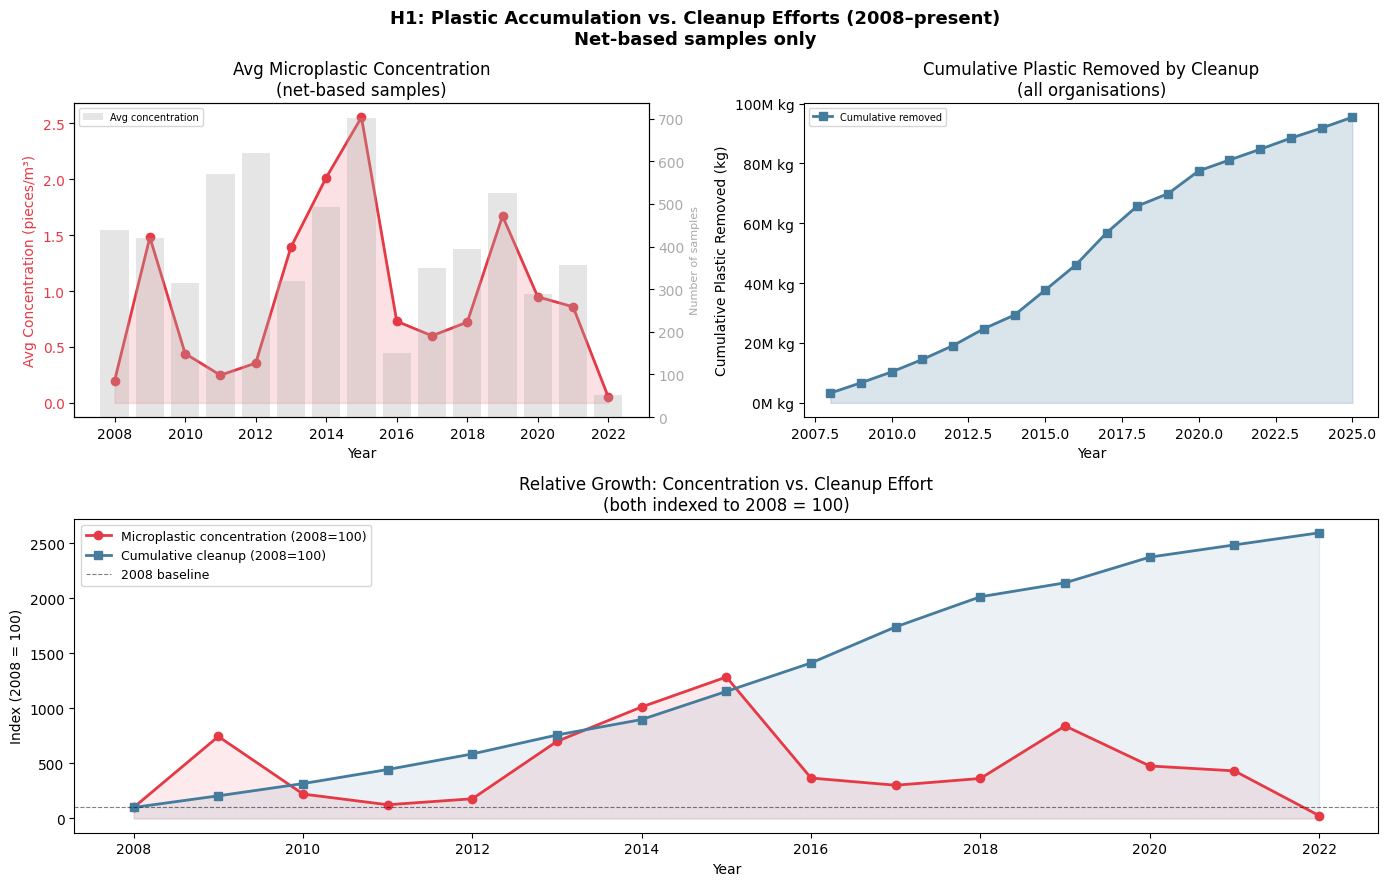

In [5]:
# ── 5: H1 — Accumulation vs cleanup chart ────────────────
plot_accumulation_vs_cleanup(
    microplastic, df_cleanup,
    save_path="../Figures/h1_accumulation_vs_cleanup.png"
)

In [6]:
# ── 6: H1 — Scale gap chart ──────────────────────────────
fig_gap = plot_scale_gap(stats)
fig_gap.show()

In [7]:
# ── 7: H1 — Cleanup growth chart ─────────────────────────
annual_org, annual_total_cumsum, yoy = get_annual_org_stats(df_cleanup)
fig_trend = plot_cleanup_growth(annual_org, annual_total_cumsum, yoy)
fig_trend.show()

#### H1 Conclusion — ✅ Supported

**The scale gap**

The Meijer 2021 dataset estimates **~1,006,000 tons** of plastic enter the ocean from rivers every year.

| Metric | Value |
|---|---|
| Annual plastic input (Meijer 2021) | ~1,006,000 t/yr |
| Best single cleanup year (2025, all orgs) | 28,629 t — **2.9% of input** |
| Entire 18-year cumulative total | 142,936 t — **14.2% of one year's input** |

Even at the record 2025 removal rate, cleanup would need to scale **~35× from current levels**
just to offset one year of new plastic input — without touching the plastic already in the ocean.

**Growth trend**

Cleanup efforts are accelerating, particularly from 2022 onwards driven by The Ocean Cleanup's
interceptor network. The cumulative curve is bending upward. However, the ICC (volunteer-dependent)
numbers are volatile, with dips in 2014, 2019 and 2020–2021.

> **Data limitation:** The 2022 concentration drop to near-zero is almost certainly a sampling
> artifact — very few net samples were taken that year, not evidence the ocean is cleaner.
> Concentration measures local density at sample points, not total ocean plastic mass.

**H1 verdict: Supported.** Cleanup is scaling and the technology is proven, but at current
scale offsets less than 3% of annual plastic input.

---
## H2 — ~100 Interceptors on the World's Most Polluting Rivers Would Offset Annual Plastic Input

**Hypothesis:** Using Guatemala's Rio Las Vacas (Interceptor 006) as a benchmark —
the highest-performing interceptor on record at ~10,000 tons/year — we calculate
how many equivalent deployments would be needed to match annual river plastic input,
and assess whether enough viable rivers exist.

**Benchmark:** Guatemala (Rio Las Vacas), deployed May 2023 — first full year removed
~10,000,000 kg = 10,000 tons.

In [10]:
# ── 8: H2 — Interceptor projection stats ─────────────────
h2_stats = get_interceptor_stats(stats, annual_org)


=== H2: INTERCEPTOR PROJECTION ===
Annual plastic input (Meijer 2021)     :  1,005,984 t/yr
Best interceptor benchmark (Guatemala) :     10,000 t/yr
Current removal (latest year, all orgs):     28,629 t/yr
Remaining gap                          :    977,355 t/yr

→ Interceptors needed to offset annual input : 101
→ Interceptors needed to close current gap   : 98
→ Currently deployed                         : ~20


In [9]:
# ── 9: H2 — Top rivers + projection chart ────────────────
top_rivers, top_pct = get_top_rivers(rivers, n=101)
fig_h2 = plot_interceptor_projection(h2_stats, top_rivers, top_pct)
fig_h2.show()

Top 101 rivers account for 34.5% of global river plastic input


#### H2 Conclusion — ✅ Supported (with important caveats)

| | Value |
|---|---|
| Annual plastic input (Meijer 2021) | 1,005,984 t/yr |
| Best interceptor benchmark (Guatemala) | 10,000 t/yr |
| Interceptors needed to match annual input | **~101** |
| Currently deployed | 22 |
| In operation | 19|
| Still needed | 81 |

**The caveat:** 101 interceptors would only work if every one performed at Guatemala scale.
In practice, the top 101 rivers by emission volume account for only **34.5% of global river
plastic input** — the remaining 65.5% is distributed across ~31,700 smaller rivers where
interceptors are less viable.

**The geography:** Of the top 101 rivers, **87 are in Asia**, 9 in Africa, 4 in South America,
1 in North America. Not a single one is in a high-income country — they are entirely in
lower-middle-income (78.5%) and upper-middle-income (21.1%) countries.

**H2 verdict: The target is ambitious but concrete.** 101 Guatemala-scale interceptors
would offset roughly **one third of annual plastic input** — the most impactful single
intervention possible. The remaining 65% requires upstream waste management improvements
alongside interceptor deployment.

---
## Q4 Summary

| Hypothesis | Result | Key Finding |
|---|---|---|
| **H1** — Accumulation outpaces cleanup | ✅ Supported | Best cleanup year = 2.8% of annual input; 18-year total = 14.2% of one year's input |
| **H2** — ~100 interceptors would offset annual river input | ✅ Supported (partial) | 101 Guatemala-scale units mathematically match input, but top 101 rivers = only 34.5% of global input; 87 are in Asia |